In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import tensorflow as tf; 
print("Tensorflow Version:",tf.__version__)
print(tf.config.list_physical_devices('GPU'))

Tensorflow Version: 2.16.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
stock_dir = 'Plots/With Technical Indicators Single LSTM'

In [5]:
import plotly
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import ta  # Technical Analysis library for Python  
import numpy as np
import os
import nltk
nltk.download('vader_lexicon')
import csv
from bs4 import BeautifulSoup
import requests
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate, Attention, MultiHeadAttention
from tensorflow.keras.utils import plot_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras import optimizers
import optuna
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/harman/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Stock Historical Data

In [ ]:

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Define global events
global_events = [
    {"label": "COVID-19 Pandemic", "start": "2020-03-01", "end": "2021-03-31", "color": "red", "alpha": 0.2},
    {"label": "Second COVID Wave", "start": "2021-03-15", "end": "2021-06-30", "color": "red", "alpha": 0.2},
    {"label": "Ukraine War", "start": "2022-02-24", "end": "2022-12-31", "color": "blue", "alpha": 0.2},
    {"label": "US Inflation Spike", "start": "2021-12-01", "end": "2022-12-01", "color": "orange", "alpha": 0.2},
    {"label": "SVB Collapse", "start": "2023-03-10", "end": "2023-03-31", "color": "purple", "alpha": 0.2},
    {"label": "Hamas-Israel Conflict", "start": "2023-10-07", "end": "2024-02-01", "color": "green", "alpha": 0.2},
]

india_events = [
    # {"label": "2019 Lok Sabha Elections", "start": "2019-04-11", "end": "2019-05-23", "color": "cyan", "alpha": 0.2},
    # {"label": "Article 370 Abrogation", "start": "2019-08-05", "end": "2019-08-10", "color": "magenta", "alpha": 0.2},
    {"label": "Farm Laws Protests", "start": "2020-10-01", "end": "2021-11-19", "color": "yellow", "alpha": 0.2},
    {"label": "Adani Group Crisis", "start": "2023-01-24", "end": "2023-02-28", "color": "black", "alpha": 0.2},
    {"label": "Ram Mandir Inauguration", "start": "2024-01-22", "end": "2024-01-23", "color": "brown", "alpha": 0.2},
    {"label": "Union Budget 2025", "start": "2025-02-01", "end": "2025-02-03", "color": "teal", "alpha": 0.2},
]

indicator_full_names = {
    'Close': 'Close Price',
    'SMA_50': 'Simple Moving Average (50-day)',
    'EMA_12': 'Exponential Moving Average (12-day)',
    'EMA_26': 'Exponential Moving Average (26-day)',
    'Aroon_Oscillator': 'Aroon Oscillator (25-day)',
    'RSI': 'Relative Strength Index (14-day)',
    'MACD': 'Moving Average Convergence Divergence',
    'ADI': 'Accumulation/Distribution Index',
    'OBV': 'On-Balance Volume',
    'SO_K': 'Stochastic Oscillator %K',
    'SO_D': 'Stochastic Oscillator %D',
    'ADX': 'Average Directional Index',
    
    # Add all the new indicators with descriptive names
    'Fib_23.6': 'Fibonacci Retracement 23.6%',
    'Fib_38.2': 'Fibonacci Retracement 38.2%',
    'Fib_61.8': 'Fibonacci Retracement 61.8%',
    'ROC': 'Price Rate of Change',
    'CCI': 'Commodity Channel Index',
    'MFI': 'Money Flow Index',
    'Williams_R': 'Williams %R',
    'Keltner_hband': 'Keltner Channel Upper Band',
    'Keltner_lband': 'Keltner Channel Lower Band',
    'Keltner_mband': 'Keltner Channel Middle Band',
    'Donchian_hband': 'Donchian Channel Upper Band',
    'Donchian_lband': 'Donchian Channel Lower Band',
    'Donchian_mband': 'Donchian Channel Middle Band',
    'VWAP': 'Volume Weighted Average Price',
    'CMF': 'Chaikin Money Flow',
    'Force_Index': 'Elder\'s Force Index',
    'Ultimate_Oscillator': 'Ultimate Oscillator',
    'ROC_10': 'Rate of Change (10-day)',
    'ROC_20': 'Rate of Change (20-day)',
    'PVT': 'Price Volume Trend',
    'NVI': 'Negative Volume Index',
    'PVI': 'Positive Volume Index',
    'Typical_Price': 'Typical Price',
    'Mass_Index': 'Mass Index',
    'Vortex_Pos': 'Vortex Indicator Positive',
    'Vortex_Neg': 'Vortex Indicator Negative',
    'Vortex_Diff': 'Vortex Indicator Difference',
    'KST': 'Know Sure Thing Oscillator',
    'KST_Signal': 'KST Signal Line',
    'KST_Diff': 'KST Difference',
    'DPO': 'Detrended Price Oscillator',
    'STC': 'Schaff Trend Cycle',
    'Coppock_Curve': 'Coppock Curve',
    'PPO': 'Percentage Price Oscillator',
    'PPO_Signal': 'PPO Signal Line',
    'PPO_Hist': 'PPO Histogram',
    'PVO': 'Percentage Volume Oscillator',
    'PVO_Signal': 'PVO Signal Line',
    'PVO_Hist': 'PVO Histogram',
    'NATR': 'Normalized Average True Range',
    'CMO': 'Chande Momentum Oscillator',
    'EOM': 'Ease of Movement',
    'VPT': 'Volume-price Trend',
    'Fisher': 'Fisher Transform',
    'Ichimoku_Conversion': 'Ichimoku Conversion Line',
    'Ichimoku_Base': 'Ichimoku Base Line',
    'Ichimoku_A': 'Ichimoku Span A',
    'Ichimoku_B': 'Ichimoku Span B',
    'Volatility_10': 'Volatility (10-day)',
    'Volatility_20': 'Volatility (20-day)',
    'Volatility_50': 'Volatility (50-day)',
    'Momentum_5': 'Price Momentum (5-day)',
    'Momentum_10': 'Price Momentum (10-day)',
    'Momentum_20': 'Price Momentum (20-day)',
    'TR': 'True Range',
    'DMP': 'Plus Directional Movement',
    'DMN': 'Minus Directional Movement',
    'Parabolic_SAR': 'Parabolic SAR',
    'TRIX': 'TRIX Indicator',
    
    # Add lagged features
    **{f'Close_Lag_{lag}': f'Close Price Lagged {lag} Days' for lag in [1, 2, 3, 5, 10]},
    **{f'Volume_Lag_{lag}': f'Volume Lagged {lag} Days' for lag in [1, 2, 3, 5, 10]},
    **{f'Pct_Change_{period}': f'Price Change Percentage ({period}-day)' for period in [1, 2, 3, 5, 10, 20]}
}


def add_technical_indicators(df):
   # Ensure we have the required columns
    close = df['Close'].squeeze().astype(float)
    high = df['High'].squeeze().astype(float)
    low = df['Low'].squeeze().astype(float)
    volume = df['Volume'].squeeze().astype(float)
    
    # Add more advanced indicators
    # Fibonacci Retracement Levels (simplified)
    max_close = close.rolling(window=50).max()
    min_close = close.rolling(window=50).min()
    diff = max_close - min_close
    
    df['Fib_23.6'] = max_close - diff * 0.236
    df['Fib_38.2'] = max_close - diff * 0.382
    df['Fib_61.8'] = max_close - diff * 0.618
    
    # Price Rate of Change
    df['ROC'] = ta.momentum.ROCIndicator(close=close).roc()
    
    # Commodity Channel Index
    df['CCI'] = ta.trend.CCIIndicator(high=high, low=low, close=close).cci()
    
    # Money Flow Index
    df['MFI'] = ta.volume.MFIIndicator(high=high, low=low, close=close, volume=volume).money_flow_index()
    
    # Williams %R
    df['Williams_R'] = ta.momentum.WilliamsRIndicator(high=high, low=low, close=close).williams_r()
    
    # Keltner Channels
    keltner = ta.volatility.KeltnerChannel(high=high, low=low, close=close)
    df['Keltner_hband'] = keltner.keltner_channel_hband()
    df['Keltner_lband'] = keltner.keltner_channel_lband()
    df['Keltner_mband'] = keltner.keltner_channel_mband()
    
    # Donchian Channel
    donchian = ta.volatility.DonchianChannel(high=high, low=low, close=close)
    df['Donchian_hband'] = donchian.donchian_channel_hband()
    df['Donchian_lband'] = donchian.donchian_channel_lband()
    df['Donchian_mband'] = donchian.donchian_channel_mband()
    
    # Volume Weighted Average Price (VWAP)
    df['VWAP'] = (df['Volume'] * (df['High'] + df['Low'] + df['Close']) / 3).cumsum() / df['Volume'].cumsum()
    
    # Chaikin Money Flow
    df['CMF'] = ta.volume.ChaikinMoneyFlowIndicator(high=high, low=low, close=close, volume=volume).chaikin_money_flow()
    
    # Elder's Force Index
    df['Force_Index'] = ta.volume.ForceIndexIndicator(close=close, volume=volume).force_index()
    
    # Ultimate Oscillator
    df['Ultimate_Oscillator'] = ta.momentum.UltimateOscillator(high=high, low=low, close=close).ultimate_oscillator()
    
    # Rate of Change (ROC)
    df['ROC_10'] = ta.momentum.ROCIndicator(close=close, window=10).roc()
    df['ROC_20'] = ta.momentum.ROCIndicator(close=close, window=20).roc()
    
    # Manual implementation of Price Volume Trend (PVT)
    df['PVT'] = ((close - close.shift(1)) / close.shift(1)) * volume
    df['PVT'] = df['PVT'].cumsum()
    
    # Manual implementation of Negative Volume Index (NVI)
    nvi = pd.Series(1000, index=df.index)  # Start with 1000
    for i in range(1, len(df)):
        if volume.iloc[i] < volume.iloc[i-1]:
            nvi.iloc[i] = nvi.iloc[i-1] + ((close.iloc[i] - close.iloc[i-1]) / close.iloc[i-1]) * nvi.iloc[i-1]
        else:
            nvi.iloc[i] = nvi.iloc[i-1]
    df['NVI'] = nvi
    
    # Manual implementation of Positive Volume Index (PVI)
    pvi = pd.Series(1000, index=df.index)  # Start with 1000
    for i in range(1, len(df)):
        if volume.iloc[i] > volume.iloc[i-1]:
            pvi.iloc[i] = pvi.iloc[i-1] + ((close.iloc[i] - close.iloc[i-1]) / close.iloc[i-1]) * pvi.iloc[i-1]
        else:
            pvi.iloc[i] = pvi.iloc[i-1]
    df['PVI'] = pvi
    
    # Typical Price
    df['Typical_Price'] = (high + low + close) / 3
    
    # Mass Index
    high_low_range = high - low
    ema_fast = high_low_range.ewm(span=9).mean()
    ema_slow = ema_fast.ewm(span=9).mean()
    ratio = ema_fast / ema_slow
    df['Mass_Index'] = ratio.rolling(window=25).sum()
    
    # Vortex Indicator
    vortex = ta.trend.VortexIndicator(high=high, low=low, close=close)
    df['Vortex_Pos'] = vortex.vortex_indicator_pos()
    df['Vortex_Neg'] = vortex.vortex_indicator_neg()
    df['Vortex_Diff'] = df['Vortex_Pos'] - df['Vortex_Neg']
    
    # KST Oscillator (Know Sure Thing)
    df['KST'] = ta.trend.KSTIndicator(close=close).kst()
    df['KST_Signal'] = ta.trend.KSTIndicator(close=close).kst_sig()
    df['KST_Diff'] = df['KST'] - df['KST_Signal']
    
    # Detrended Price Oscillator
    df['DPO'] = ta.trend.DPOIndicator(close=close).dpo()
    
    # Schaff Trend Cycle
    df['STC'] = ta.trend.STCIndicator(close=close).stc()
    
    # Coppock Curve
    roc_14 = close.pct_change(periods=14)
    roc_11 = close.pct_change(periods=11)
    sum_roc = roc_14 + roc_11
    df['Coppock_Curve'] = sum_roc.rolling(window=10).apply(lambda x: 
                                                      np.sum(x * np.arange(1, 11)) / np.sum(np.arange(1, 11)))
    
    # Percentage Price Oscillator
    ppo = ta.momentum.PercentagePriceOscillator(close=close)
    df['PPO'] = ppo.ppo()
    df['PPO_Signal'] = ppo.ppo_signal()
    df['PPO_Hist'] = ppo.ppo_hist()
    
    # Percentage Volume Oscillator
    ema_12_volume = volume.ewm(span=12).mean()
    ema_26_volume = volume.ewm(span=26).mean()
    df['PVO'] = ((ema_12_volume - ema_26_volume) / ema_26_volume) * 100

    # Signal line = 9-day EMA of PVO
    df['PVO_Signal'] = df['PVO'].ewm(span=9).mean()

    # PVO Histogram = PVO - Signal line
    df['PVO_Hist'] = df['PVO'] - df['PVO_Signal']
    
    # Normalized Average True Range
    atr = ta.volatility.AverageTrueRange(high=high, low=low, close=close).average_true_range()
    df['NATR'] = (atr / close) * 100
    
    # Chande Momentum Oscillator
    # CMO = 100 * (sum of recent gains - sum of recent losses) / (sum of recent gains + sum of recent losses)
    # Typically uses a 14-day period

    # Calculate price changes
    price_changes = close.diff()

    # Separate gains and losses
    gains = price_changes.where(price_changes > 0, 0)
    losses = -price_changes.where(price_changes < 0, 0)

    # Calculate sum of gains and losses over 14 periods
    sum_gains = gains.rolling(window=14).sum()
    sum_losses = losses.rolling(window=14).sum()

    # Calculate CMO
    df['CMO'] = 100 * (sum_gains - sum_losses) / (sum_gains + sum_losses)
    
    # Ease of Movement
    df['EOM'] = ta.volume.EaseOfMovementIndicator(high=high, low=low, volume=volume).ease_of_movement()
    
    # Manual implementation of Volume-price Trend
    df['VPT'] = volume * ((close - close.shift(1)) / close.shift(1))
    df['VPT'] = df['VPT'].cumsum()
    
    # Fisher Transform calculation
    period = 9  # Typical period for Fisher Transform

    # Calculate the midpoint price
    mid_price = (high + low) / 2

    # Normalize the price over the period
    lowest_low = mid_price.rolling(window=period).min()
    highest_high = mid_price.rolling(window=period).max()

    # Avoid division by zero
    diff = highest_high - lowest_low
    diff = diff.where(diff != 0, 1)  # Replace zeros with 1

    # Normalize to range between -1 and 1
    normalized = 2 * ((mid_price - lowest_low) / diff) - 1

    # Apply smoothing with EMA
    smoothed = normalized.ewm(span=3).mean()

    # Apply Fisher transformation: 0.5 * ln((1 + x) / (1 - x))
    # Clamp values to avoid log of negative numbers
    smoothed = smoothed.clip(-0.999, 0.999)
    df['Fisher'] = 0.5 * np.log((1 + smoothed) / (1 - smoothed))
    
    # Ichimoku Cloud
    ichimoku = ta.trend.IchimokuIndicator(high=high, low=low)
    df['Ichimoku_Conversion'] = ichimoku.ichimoku_conversion_line()
    df['Ichimoku_Base'] = ichimoku.ichimoku_base_line()
    df['Ichimoku_A'] = ichimoku.ichimoku_a()
    df['Ichimoku_B'] = ichimoku.ichimoku_b()
    
    # Add lagged features for momentum
    for lag in [1, 2, 3, 5, 10]:
        df[f'Close_Lag_{lag}'] = close.shift(lag)
        df[f'Volume_Lag_{lag}'] = volume.shift(lag)
    
    # Add price change percentages
    for period in [1, 2, 3, 5, 10, 20]:
        df[f'Pct_Change_{period}'] = close.pct_change(period)
    
    # Add volatility measures
    df['Volatility_10'] = close.pct_change().rolling(window=10).std()
    df['Volatility_20'] = close.pct_change().rolling(window=20).std()
    df['Volatility_50'] = close.pct_change().rolling(window=50).std()
    
    # Add price momentum
    df['Momentum_5'] = close.diff(5)
    df['Momentum_10'] = close.diff(10)
    df['Momentum_20'] = close.diff(20)
    
   # True Range = max(high - low, abs(high - previous_close), abs(low - previous_close))
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    df['TR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    
    # Add Average Directional Movement Index (ADX)
    adx = ta.trend.ADXIndicator(high=high, low=low, close=close)
    df['ADX'] = adx.adx()
    df['DMP'] = adx.adx_pos()
    df['DMN'] = adx.adx_neg()
    
    # Add Parabolic SAR
    df['Parabolic_SAR'] = ta.trend.PSARIndicator(high=high, low=low, close=close).psar()
    
    # Add Trix Indicator
    df['TRIX'] = ta.trend.TRIXIndicator(close=close).trix()
    
    return df

# Stock names and Yahoo tickers
nifty50_tickers = {
    "Adani Enterprises": "ADANIENT.NS"
    # "Adani Ports & SEZ": "ADANIPORTS.NS",
    # "Apollo Hospitals": "APOLLOHOSP.NS",
    # "Axis Bank": "AXISBANK.NS",
    # "Bajaj Auto": "BAJAJ-AUTO.NS",
    # "Cipla": "CIPLA.NS",
    # "HCL Technologies": "HCLTECH.NS",
    # "HDFC Bank": "HDFCBANK.NS",
    # "Infosys": "INFY.NS",
    # "Larsen & Toubro": "LT.NS",
    # "Mahindra & Mahindra": "M&M.NS",
    # "Maruti Suzuki": "MARUTI.NS",
    # "Nestle India": "NESTLEIND.NS",
    # "NTPC": "NTPC.NS",
    # "Power Grid Corporation": "POWERGRID.NS",
    # "Reliance Industries": "RELIANCE.NS",
    # "State Bank of India": "SBIN.NS",
    # "Tata Consultancy Services": "TCS.NS",
    # "Tata Motors": "TATAMOTORS.NS",
    # "Trent": "TRENT.NS"
    
}

# Define date range
start_date = "2020-04-01"
end_date = "2025-03-31"

for name, ticker in nifty50_tickers.items():
    if ticker == 'NA':
        continue

    print(f"Processing {name} ({ticker})...")
    stock_dir = os.path.join("Nifty50_Stocks_With_Technical_Indicators", name.replace(" ", "_"))
    os.makedirs(stock_dir, exist_ok=True)

    df = yf.download(ticker, start=start_date, end=end_date, group_by='ticker')

    # Drop extra top-level MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(0)

    # Flatten if multi-index (like: ('Close', 'RELIANCE.NS'))
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Strip whitespaces and ensure lower-case consistency
    df.columns = [col.strip() for col in df.columns]

    # Remove any rows where 'Open' is not a number (this eliminates 'Price', 'Ticker' rows)
    if 'Open' in df.columns:
        df = df[pd.to_numeric(df['Open'], errors='coerce').notna()]
    else:
        print(f"Skipped {ticker}: 'Open' column missing after cleaning.")
        continue

    # Check required columns
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    if not all(col in df.columns for col in required_cols):
        print(f"Skipped {ticker}: Missing expected columns. Found: {df.columns.tolist()}")
        continue

    df = df[required_cols].dropna()
    df = add_technical_indicators(df)
    df.index.name = 'Date'  # name the index for CSV header
    df.to_csv(os.path.join(stock_dir, f"{ticker}_data.csv"), index=True)

    indicators = [col for col in df.columns if col in indicator_full_names]
    for indicator in indicators:
        if indicator not in df.columns:
            continue

        plt.figure(figsize=(14, 6))
        plt.plot(df.index, df[indicator], label=indicator, linewidth=2)
        
        for event in global_events + india_events:
            start = pd.to_datetime(event['start'])
            end = pd.to_datetime(event['end'])
            plt.axvspan(pd.to_datetime(event['start']), pd.to_datetime(event['end']),
                        color=event['color'], alpha=event['alpha'], label=event['label'])
        # Annotate stock price (only for indicators that exist in df)
        if indicator == 'Close':
            if start in df.index and end in df.index:
                start_price = float(df.loc[start, 'Close']) if start in df.index else None
                end_price = float(df.loc[end, 'Close']) if end in df.index else None

        full_name = indicator_full_names.get(indicator, indicator)
        plt.title(f"{name} - {full_name} with Events")
        plt.xlabel("Date")
        plt.ylabel(indicator)
        plt.legend(loc="upper left", fontsize='small', ncol=2)
        plt.tight_layout()
        plt.savefig(os.path.join(stock_dir, f"{ticker}_{indicator}_events_Today.png"))
        plt.close()

    print(f"Completed {name}")

# Sentiment Analysis

In [ ]:
import nltk
nltk.download('vader_lexicon')
import csv
from bs4 import BeautifulSoup
import requests
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Define base folder for saving
base_folder = os.path.join(os.getcwd(), "Nifty50_Stocks_With_Technical_Indicators", "Adani_Enterprises")
os.makedirs(base_folder, exist_ok=True)

# Base URL pattern for the pages
base_url = "https://www.moneycontrol.com/news/tags/adani.html/page-"

# User-Agent header for the request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'}

# Function to fetch complete news content and publication date
def fetch_complete_news_and_date(link):
    try:
        response = requests.get(link, headers=headers, timeout=30)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Extract article content
        article_content_div = soup.find('div', class_='content_wrapper')
        article_content = article_content_div.text.strip() if article_content_div else None

        # Extract publication date
        date_tag = soup.find('div', class_='article_schedule')
        date = date_tag.text.strip() if date_tag else None

        return {
            'Content': article_content,
            'Date': date
        }
    except Exception as e:
        print(f"Failed to fetch complete news from {link}: {e}")
        return {'Content': None, 'Date': None}

# Function to normalize dates
def normalize_date(raw_date):
    try:
        # Remove time component if present
        if '/' in raw_date:
            clean_date = raw_date.split('/')[0].strip()  # Keep only the date part
        else:
            clean_date = raw_date.strip()
        
        # Try parsing the cleaned date
        return pd.to_datetime(clean_date).strftime("%Y-%m-%d")
    except Exception as e:
        print(f"Error parsing date: {e}")
        return None  # Return None if the date cannot be parsed

# Function to scrape data from a single page
def scrape_page(page_url, analyzer, daily_sentiments):
    request = requests.get(page_url, headers=headers)
    soup = BeautifulSoup(request.text, 'html.parser')
    news_items = soup.select('li.clearfix')

    page_news_list = []

    for item in news_items:
        link_tag = item.find('a', href=True)
        link = link_tag['href'] if link_tag else None
        title = link_tag['title'] if link_tag else None

        # Fetch complete news content and date
        if link:
            news_data = fetch_complete_news_and_date(link)
            complete_news = news_data['Content']
            date = news_data['Date']

            # Perform sentiment analysis if content is available
            if complete_news and date:
                try:
                    # Normalize the date
                    formatted_date = normalize_date(date)
                    if not formatted_date:
                        continue  # Skip if date cannot be parsed

                    # Perform sentiment analysis
                    sentiment_score = analyzer.polarity_scores(complete_news)['compound']

                    # Aggregate sentiment scores by date
                    if formatted_date in daily_sentiments:
                        daily_sentiments[formatted_date].append(sentiment_score)
                    else:
                        daily_sentiments[formatted_date] = [sentiment_score]

                except Exception as e:
                    print(f"Error processing news item: {e}")
                    continue

        page_news_list.append({
            'date': date,
            'title': title,
            'link': link,
            'complete_news': complete_news
        })

    return page_news_list, daily_sentiments

# Scraping from multiple pages
def scrape_news(start_page=1, end_page=3):
    news_list = []
    analyzer = SentimentIntensityAnalyzer()
    daily_sentiments = {}  # To store sentiment scores by date

    for page_number in range(start_page, end_page + 1):
        page_url = f"{base_url}{page_number}/"
        print(f"Scraping: {page_url}")
        scraped_data, daily_sentiments = scrape_page(page_url, analyzer, daily_sentiments)
        news_list.extend(scraped_data)

    # Calculate average sentiment for each date
    daily_sentiments_avg = {date: sum(scores) / len(scores) for date, scores in daily_sentiments.items()}

    return news_list, daily_sentiments_avg

# Main Execution
news_list, daily_sentiments_avg = scrape_news(start_page=1, end_page=30)

# Save the news data to a CSV file
news_csv_file = os.path.join(base_folder, "ADANIENT_scraped_news_with_content.csv")
news_csv_headers = ['date', 'title', 'link', 'complete_news']

with open(news_csv_file, mode="w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=news_csv_headers)
    writer.writeheader()
    writer.writerows(news_list)

print(f"Scraped news data saved to {news_csv_file}")

# Save sentiment data
sentiments_csv_file = os.path.join(base_folder, "ADANIENT_daily_sentiments.csv")

sentiments_df = pd.DataFrame(daily_sentiments_avg.items(), columns=["Date", "Average Sentiment"])
sentiments_df.to_csv(sentiments_csv_file, index=False)

print(f"Daily sentiments saved to {sentiments_csv_file}")

### Merge Stock Historical Data, NSE Historical Data with Sentiment Analysis

In [ ]:
import pandas as pd
import os
import yfinance as yf

# Load Adani Enterprises Historical Data
stock_historical_data_path = "Nifty50_Stocks_With_Technical_Indicators/Adani_Enterprises/ADANIENT.NS_data.csv"
ADANIENT_data = pd.read_csv(stock_historical_data_path)

# Convert Date to datetime
ADANIENT_data["Date"] = pd.to_datetime(ADANIENT_data["Date"])

# Filter rows between 2019-04-01 and 2025-03-31
mask = (ADANIENT_data["Date"] >= "2019-04-01") & (ADANIENT_data["Date"] <= "2025-03-31")
ADANIENT_data = ADANIENT_data.loc[mask]

# Remove rows with missing OHLC values and weekends
ADANIENT_data = ADANIENT_data.dropna(subset=["Open", "Close"], how="any")
ADANIENT_data = ADANIENT_data[ADANIENT_data["Date"].dt.weekday < 5]

# Load Sentiment Data
sentiment_file_path = "Nifty50_Stocks_With_Technical_Indicators/Adani_Enterprises/ADANIENT_daily_sentiments.csv"
sentiment_complete = pd.read_csv(sentiment_file_path)

# Convert Date to datetime
sentiment_complete["Date"] = pd.to_datetime(sentiment_complete["Date"])

# Filter sentiment data for same date range
sentiment_complete = sentiment_complete[
    (sentiment_complete["Date"] >= "2019-04-01") &
    (sentiment_complete["Date"] <= "2025-03-31")
]

# Download Nifty data for the same date range
print("Downloading Nifty index data...")
nifty_data = yf.download("^NSEI", start="2019-04-01", end="2025-03-31")
# Check if nifty_data has MultiIndex columns and flatten them
if isinstance(nifty_data.columns, pd.MultiIndex):
    nifty_data.columns = nifty_data.columns.get_level_values(0)

# Reset index and prepare nifty_data for merging
nifty_data.reset_index(inplace=True)
nifty_data["Date"] = pd.to_datetime(nifty_data["Date"])
nifty_data = nifty_data[["Date", "Close"]]
nifty_data.rename(columns={"Close": "Nifty_Close"}, inplace=True)

# Merge Stock Data with Sentiment Data (Keep Only Stock Dates)
merged_data = pd.merge(
    ADANIENT_data,
    sentiment_complete,
    on="Date",
    how="left"  # keeps only stock dates
)

# Merge with Nifty data
merged_data = pd.merge(
    merged_data,
    nifty_data,
    on="Date",
    how="left"  # keeps only stock dates
)

# Fill Missing Sentiment Values
merged_data["Average Sentiment"] = (
    merged_data["Average Sentiment"]
    .fillna(method="ffill")
    .fillna(method="bfill")
)

# Fill Missing Nifty Values (if any)
merged_data["Nifty_Close"] = (
    merged_data["Nifty_Close"]
    .fillna(method="ffill")
    .fillna(method="bfill")
)

# Sort by Date
merged_data = merged_data.sort_values("Date").reset_index(drop=True)

# Save Final Merged File
output_path = "Nifty50_Stocks_With_Technical_Indicators/Adani_Enterprises/ADANIENT_with_sentiment_and_nifty_final.csv"
merged_data.to_csv(output_path, index=False)

print(f"Final merged dataset saved to: {output_path}")
print(f"Dataset includes {len(merged_data)} rows with columns: {list(merged_data.columns)}")

In [ ]:
merged_data.columns 

 ### Data Preparation and Feature Engineering

In [6]:
# Load your merged data
merged_data = pd.read_csv("Nifty50_Stocks_With_Technical_Indicators/Adani_Enterprises/ADANIENT_with_sentiment_and_nifty_final.csv")

# Convert Date to datetime
merged_data["Date"] = pd.to_datetime(merged_data["Date"])

# Create additional features
merged_data['Price_Change'] = merged_data['Close'].pct_change()
merged_data['Nifty_Price_Change'] = merged_data['Nifty_Close'].pct_change()
merged_data['Volume_Change'] = merged_data['Volume'].pct_change()



In [7]:
# Calculate daily returns
merged_data['Returns'] = merged_data['Close'].pct_change() * 100
merged_data.dropna(inplace=True)
merged_data.reset_index(drop=True, inplace=True)

In [8]:
merged_data

,Date,Open,High,Low,Close,Volume,Fib_23.6,Fib_38.2,Fib_61.8,ROC,...,DMP,DMN,Parabolic_SAR,TRIX,Average Sentiment,Nifty_Close,Price_Change,Nifty_Price_Change,Volume_Change,Returns
0,2020-07-17,149.375733,153.515355,148.627607,151.221115,2222846,160.137746,155.441015,147.849039,-3.837598,...,21.982126,22.660605,165.873332,0.227975,0.9955,10901.700195,0.018133,0.015061,0.508258,1.813308
1,2020-07-20,152.767237,161.495368,151.719873,160.298370,6329853,160.137746,155.441015,147.849039,1.580273,...,27.954057,20.230497,164.190433,0.198098,0.9955,11022.200195,0.060026,0.011053,1.847635,6.002637
2,2020-07-21,161.046496,167.679885,158.702378,166.881882,6517373,160.137746,155.441015,147.849039,4.562519,...,31.706257,18.376120,144.837098,0.186747,0.9955,11162.250000,0.041070,0.012706,0.029625,4.107036
3,2020-07-22,166.582598,171.570101,161.595095,168.976593,4611051,161.090356,156.211582,148.325344,3.166856,...,32.427138,16.559814,145.293954,0.190491,0.9955,11132.599609,0.012552,-0.002656,-0.292499,1.255206
4,2020-07-23,167.929246,170.273364,164.986607,169.525238,2199241,161.509521,156.550644,148.534927,1.070482,...,30.695449,15.675479,146.344999,0.204414,0.9955,11215.450195,0.003247,0.007442,-0.523050,0.324687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,2025-03-24,2368.788886,2393.776111,2359.893532,2367.489502,1010184,2359.748776,2309.141847,2227.338866,5.470084,...,24.076020,17.478910,2188.045362,-0.018221,-0.9988,23658.349609,0.002497,0.013188,-0.082833,0.249703
1159,2025-03-25,2383.781170,2386.429718,2313.916990,2319.164307,763065,2359.748776,2309.141847,2227.338866,2.996208,...,22.202500,21.052716,2216.847667,0.016456,-0.9988,23668.650391,-0.020412,0.000435,-0.244628,-2.041200
1160,2025-03-26,2323.711732,2358.644065,2306.870489,2311.418213,1078870,2359.748776,2309.141847,2227.338866,2.896559,...,20.949025,20.632539,2241.617649,0.045496,-0.9988,23486.849609,-0.003340,-0.007681,0.413864,-0.334004
1161,2025-03-27,2308.819500,2372.686747,2290.429001,2362.142334,1696042,2359.748776,2309.141847,2227.338866,6.060672,...,19.103653,20.575742,2262.919834,0.073825,0.1531,23591.949219,0.021945,0.004475,0.572054,2.194502


In [ ]:
# Select features for model
feature_columns = [
    'Close', 'Volume',
       'Fib_38.2', 'ROC', 'CCI', 'MFI', 'Williams_R',
       'Keltner_hband', 'Keltner_lband', 'Keltner_mband', 'Donchian_hband',
       'Donchian_lband', 'Donchian_mband', 'VWAP', 'CMF', 'Force_Index',
       'Ultimate_Oscillator', 'ROC_20', 'PVT', 'NVI', 'PVI',
       'Typical_Price', 'Mass_Index', 'Vortex_Pos', 'Vortex_Neg',
       'Vortex_Diff', 'KST', 'KST_Signal', 'KST_Diff', 'DPO', 'STC',
       'Coppock_Curve', 'PPO', 'PPO_Signal', 'PPO_Hist', 'PVO', 'PVO_Signal',
       'PVO_Hist', 'NATR', 'CMO', 'EOM', 'VPT', 'Fisher',
       'Ichimoku_Conversion', 'Ichimoku_Base', 'Ichimoku_A', 'Ichimoku_B',
       'Close_Lag_5', 'Volume_Lag_5',
       'Momentum_10', 'TR', 'ADX', 'DMP', 'DMN',
       'Parabolic_SAR', 'TRIX', 'Average Sentiment', 'Price_Change', 'Nifty_Price_Change',
    'Volume_Change', 'Returns'
]

In [9]:
# Select features for model
refined_feature_columns = [
    'Close', 'Volume',
       'Fib_38.2', 'ROC', 'Williams_R',
       'Keltner_hband', 'Donchian_hband',
       'Donchian_lband', 'Donchian_mband', 'PVT', 'PVI',
        'Mass_Index', 
       'Vortex_Diff', 
       'Coppock_Curve',
       'Ichimoku_Conversion', 'Ichimoku_Base', 'Ichimoku_A',
       'Close_Lag_5', 'Volume_Lag_5',
       'Momentum_10', 'TR', 'ADX', 
       'Average Sentiment', 'Returns'
]

In [10]:
merged_data_features = merged_data[refined_feature_columns ].copy()
merged_data_target = merged_data[['Close']].copy()

In [11]:
merged_data_features

,Close,Volume,Fib_38.2,ROC,Williams_R,Keltner_hband,Donchian_hband,Donchian_lband,Donchian_mband,PVT,...,Ichimoku_Conversion,Ichimoku_Base,Ichimoku_A,Close_Lag_5,Volume_Lag_5,Momentum_10,TR,ADX,Average Sentiment,Returns
0,151.221115,2222846,155.441015,-3.837598,-74.852584,164.438817,170.223473,144.837098,157.530285,1.507822e+06,...,157.530285,155.435535,156.482910,159.300842,1950837.0,-8.378983,4.987507,19.953382,0.9955,1.813308
1,160.298370,6329853,155.441015,1.580273,-39.096178,164.968325,170.223473,144.837098,157.530285,1.887780e+06,...,156.956729,156.308347,156.632538,155.659988,2585981.0,-3.491241,10.274253,19.673077,0.9955,6.002637
2,166.881882,6517373,155.441015,4.562519,-13.162930,165.437151,170.223473,144.837098,157.530285,2.155451e+06,...,156.258492,156.308347,156.283419,149.375748,2352010.0,-0.847839,8.977507,20.169030,0.9955,4.107036
3,168.976593,4611051,156.211582,3.166856,-9.701520,165.995751,171.570101,144.837098,158.203599,2.213330e+06,...,158.203599,157.330789,157.767194,147.380722,2180415.0,6.383987,9.975006,21.042022,0.9955,1.255206
4,169.525238,2199241,156.550644,1.070482,-7.649206,165.821188,171.570101,144.837098,158.203599,2.220470e+06,...,158.203599,158.203599,158.203599,148.527847,1473784.0,7.182007,5.286757,21.852658,0.9955,0.324687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,2367.489502,1010184,2309.141847,5.470084,-8.349218,2276.985758,2393.776111,2025.514297,2209.645204,5.577456e+07,...,2286.805705,2209.645204,2248.225454,2251.548828,927737.0,121.138184,33.882579,19.023503,-0.9988,0.249703
1159,2319.164307,763065,2309.141847,2.996208,-30.228774,2286.030286,2393.776111,2025.514297,2209.645204,5.575899e+07,...,2286.805705,2209.645204,2248.225454,2251.548828,0.0,92.002930,72.512729,17.854549,-0.9988,-2.041200
1160,2311.418213,1078870,2309.141847,2.896559,-38.495646,2297.027174,2393.776111,2025.514297,2209.645204,5.575538e+07,...,2295.326470,2209.645204,2252.485837,2317.464844,1030345.0,61.968262,51.773576,16.633590,-0.9988,-0.334004
1161,2362.142334,1696042,2309.141847,6.060672,-14.786228,2308.966053,2393.776111,2025.514297,2209.645204,5.579260e+07,...,2295.326470,2209.645204,2252.485837,2338.104492,2587050.0,121.488037,82.257746,15.710473,0.1531,2.194502


In [12]:
merged_data_target

,Close
0,151.221115
1,160.298370
2,166.881882
3,168.976593
4,169.525238
...,...
1158,2367.489502
1159,2319.164307
1160,2311.418213
1161,2362.142334


# SHAP + PCA

In [ ]:
import shap
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [ ]:
# --------------------------
# Clean features and target
# --------------------------
# Drop any columns that are not numeric (e.g. datetime, string labels)
merged_data_features = merged_data_features.select_dtypes(include=[np.number])

# Fill NaN or Inf values with 0 (or forward fill if time-series)
merged_data_features = merged_data_features.replace([np.inf, -np.inf], np.nan).fillna(0)
merged_data_target = merged_data_target.replace([np.inf, -np.inf], np.nan).fillna(0)

# Ensure target is 1D numpy array
merged_data_target = np.ravel(merged_data_target)


In [ ]:
print("Feature shape:", merged_data_features.shape)
print("Target shape:", merged_data_target.shape)
print("Feature dtypes:\n", merged_data_features.dtypes.head())


In [ ]:
# --------------------------
# XGBoost for SHAP importance
# --------------------------
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(merged_data_features, merged_data_target)

In [ ]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(merged_data_features)

shap_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": merged_data_features.columns,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

print("\n🔹 Top 20 SHAP Features:")
print(importance_df.head(20))

In [ ]:
# --------------------------
# Select relevant features
# --------------------------
momentum_features   = [f for f in merged_data_features.columns if "RSI" in f or "MACD" in f or "Momentum" in f]
volume_features     = [f for f in merged_data_features.columns if "Volume" in f or "OBV" in f or "Chaikin" in f]
volatility_features = [f for f in merged_data_features.columns if "Bollinger" in f or "ATR" in f or "Volatility" in f]
sentiment_features  = [f for f in merged_data_features.columns if "sentiment" in f.lower()]

In [ ]:
selected_groups = momentum_features + volume_features + volatility_features + sentiment_features
top_shap_features = importance_df.head(30)["feature"].tolist()
final_features = [f for f in selected_groups if f in top_shap_features]

X_selected = merged_data_features[final_features]

print("\n✅ Final Selected Features:")
print(final_features)

In [ ]:
# --------------------------
# PCA Dimensionality Reduction
# --------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

pca = PCA(n_components=0.95, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal features: {X_selected.shape[1]} → Reduced to: {X_pca.shape[1]} with PCA")

### Train, validation and test split

In [13]:
# ===== PARAMETERS =====

# Split into train/val/test *before* scaling
X_train_data, X_temp, y_train_data, y_temp = train_test_split(
    merged_data_features, merged_data_target, test_size=0.20, shuffle=False
)
X_val_data, X_test_data, y_val_data, y_test_data = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False
)

In [14]:
import numpy as np

# Check for infinite values
print("Infinite values in test set:", np.any(np.isinf(X_test_data)))

# Check for very large values
print("Max value in test set:", np.nanmax(X_test_data))
print("Min value in test set:", np.nanmin(X_test_data))

Infinite values in test set: False
Max value in test set: 57591372.84858896
Min value in test set: -817.831787109375


In [15]:
# Replace infinite values with NaN
X_train_data = np.where(np.isinf(X_train_data), np.nan, X_train_data)
X_val_data = np.where(np.isinf(X_val_data), np.nan, X_val_data)
X_test_data = np.where(np.isinf(X_test_data), np.nan, X_test_data)

# Calculate mean from training data (to avoid data leakage)
train_mean = np.nanmean(X_train_data, axis=0)

# Fill NaN values with training mean
X_train_data = np.where(np.isnan(X_train_data), train_mean, X_train_data)
X_val_data = np.where(np.isnan(X_val_data), train_mean, X_val_data)
X_test_data = np.where(np.isnan(X_test_data), train_mean, X_test_data)

# Clip extreme values to reasonable range
max_val = np.percentile(X_train_data, 99.9)  # 99.9th percentile of training data
min_val = np.percentile(X_train_data, 0.1)   # 0.1th percentile of training data

X_train_data = np.clip(X_train_data, min_val, max_val)
X_val_data = np.clip(X_val_data, min_val, max_val)
X_test_data = np.clip(X_test_data, min_val, max_val)

In [16]:
# ===== PARAMETERS =====
LAG_DAYS = 5

# Split into train/val/test *before* scaling
X_train_data, X_temp, y_train_data, y_temp = train_test_split(
    merged_data_features, merged_data_target, test_size=0.20, shuffle=False
)
X_val_data, X_test_data, y_val_data, y_test_data = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False
)

# Scale features — fit on training set, transform all sets
feature_scaler = MinMaxScaler()
X_train_data = feature_scaler.fit_transform(X_train_data)
X_val_data   = feature_scaler.transform(X_val_data)
X_test_data  = feature_scaler.transform(X_test_data)

# Scale target — fit on training set, transform all sets
target_scaler = MinMaxScaler()
y_train_data = target_scaler.fit_transform(y_train_data)
y_val_data   = target_scaler.transform(y_val_data)
y_test_data  = target_scaler.transform(y_test_data)

# Create time series generators
train_gen = TimeseriesGenerator(X_train_data, y_train_data, length=LAG_DAYS, batch_size=1)
val_gen   = TimeseriesGenerator(X_val_data, y_val_data, length=LAG_DAYS, batch_size=1)
test_gen  = TimeseriesGenerator(X_test_data, y_test_data, length=LAG_DAYS, batch_size=1)

# Convert generators to arrays for Optuna
def to_xy(generator):
    X, y = [], []
    for i in range(len(generator)):
        xi, yi = generator[i]
        X.append(xi[0])
        y.append(yi[0])
    return np.array(X), np.array(y)

x_train, y_train = to_xy(train_gen)
x_val, y_val     = to_xy(val_gen)
x_test, y_test   = to_xy(test_gen)

In [17]:

# Create time series generators
train_gen = TimeseriesGenerator(X_train_data, y_train_data, length=LAG_DAYS, batch_size=1)
val_gen   = TimeseriesGenerator(X_val_data, y_val_data, length=LAG_DAYS, batch_size=1)
test_gen  = TimeseriesGenerator(X_test_data, y_test_data, length=LAG_DAYS, batch_size=1)


# Convert generators to arrays for Optuna
def to_xy(generator):
    X, y = [], []
    for i in range(len(generator)):
        xi, yi = generator[i]
        X.append(xi[0])
        y.append(yi[0])
    return np.array(X), np.array(y)

x_train, y_train = to_xy(train_gen)
x_val, y_val     = to_xy(val_gen)
x_test, y_test   = to_xy(test_gen)

### Optuna Optimization

In [18]:
def run(trial):
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "Adagrad", "Adamax", "Nadam", "RMSprop", "SGD"])
    optimizer_class = getattr(tf.keras.optimizers, optimizer_name)

    units = trial.suggest_int("units", 50, 2000, step=50)
    epochs = trial.suggest_int("epochs", 100, 1500, step=50)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-1)

    model = Sequential([
        LSTM(units=units, input_shape=(x_train.shape[1], x_train.shape[2])),
        Dropout(rate=dropout_rate),
        Dense(1)
    ])
    model.compile(
        loss="mean_squared_error",
        optimizer=optimizer_class(learning_rate=learning_rate)
    )

    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    model.fit(x_train, y_train, 
              validation_data=(x_val, y_val), 
              epochs=epochs, 
              batch_size=batch_size, 
              callbacks=[es], 
              verbose=0)

    y_val_pred = model.predict(x_val, verbose=0)
    y_val_pred_inv = target_scaler.inverse_transform(y_val_pred)
    y_val_inv = target_scaler.inverse_transform(y_val)

    rmse = np.sqrt(mean_squared_error(y_val_inv, y_val_pred_inv))
    return rmse

In [19]:
study = optuna.create_study(direction="minimize")
study.optimize(run, n_trials=20)

best_params = study.best_params
print("Best Params:", best_params)

[I 2025-09-02 15:14:54,596] A new study created in memory with name: no-name-ca1bbb9b-a34d-4590-858c-356e6084204e
2025-09-02 15:14:54.603497: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-02 15:14:54.603561: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-02 15:14:54.603574: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-02 15:14:54.695864: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your ker

[I 2025-09-02 15:21:51,350] Trial 2 finished with value: 85.01128271510673 and parameters: {'optimizer': 'Adamax', 'units': 850, 'epochs': 950, 'batch_size': 32, 'dropout_rate': 0.11384142243859402, 'learning_rate': 0.0019739639468666003}. Best is trial 2 with value: 85.01128271510673.
[I 2025-09-02 15:23:41,071] Trial 3 finished with value: 84.790890320972 and parameters: {'optimizer': 'Adamax', 'units': 1250, 'epochs': 750, 'batch_size': 32, 'dropout_rate': 0.46502932651230855, 'learning_rate': 0.0067114114121850366}. Best is trial 3 with value: 84.790890320972.
[I 2025-09-02 15:25:05,569] Trial 4 finished with value: 86.13633953183378 and parameters: {'optimizer': 'Adamax', 'units': 1600, 'epochs': 1300, 'batch_size': 64, 'dropout_rate': 0.2046525041090745, 'learning_rate': 0.00018166394277451697}. Best is trial 3 with value: 84.790890320972.
[I 2025-09-02 15:25:27,737] Trial 5 finished with value: 101.81521054927624 and parameters: {'optimizer': 'Adamax', 'units': 850, 'epochs': 85

Best Params: {'optimizer': 'Adamax', 'units': 1250, 'epochs': 750, 'batch_size': 32, 'dropout_rate': 0.46502932651230855, 'learning_rate': 0.0067114114121850366}


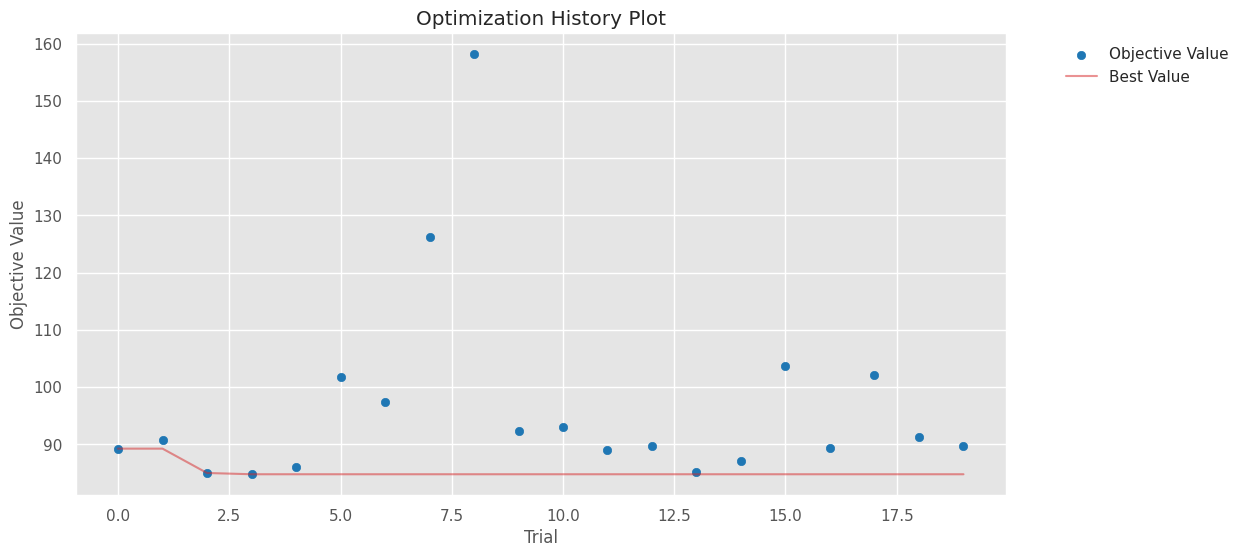

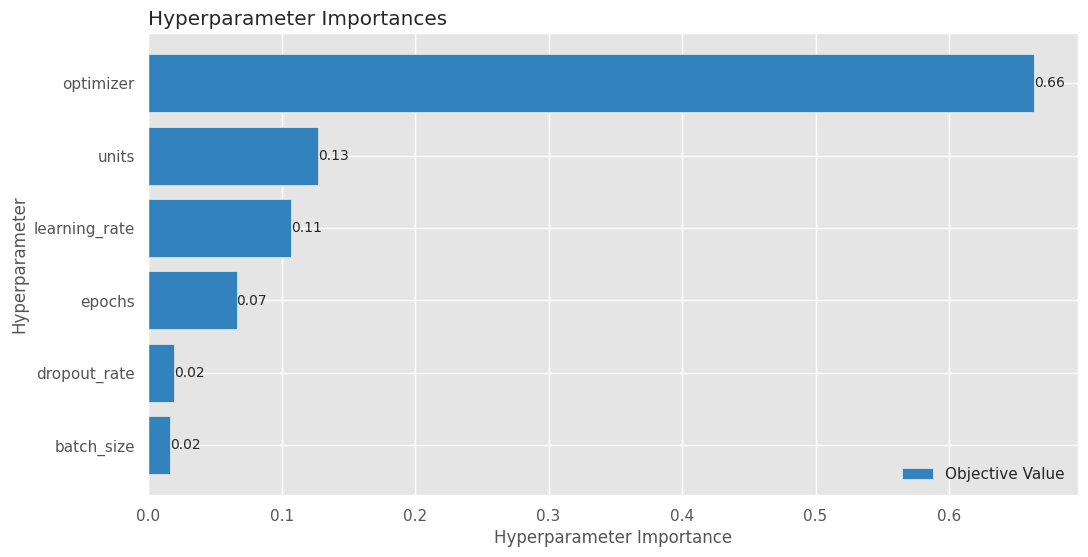

In [55]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
plot_optimization_history(study);
plt.savefig(os.path.join(stock_dir, 'optuna_optimization_history.png'))
plot_param_importances(study);
plt.savefig(os.path.join(stock_dir, 'optuna_param_importances.png'))

optuna.visualization.plot_slice(study, params=['epochs', 'learning_rate'])
plt.savefig(os.path.join(stock_dir, 'optuna_plot_slice_epochs_learning_rate.png'))


# Single LSTM

In [56]:
from tensorflow.keras import regularizers
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential([
    LSTM(
        units=best_params["units"],
        input_shape=(x_train.shape[1], x_train.shape[2]),
        kernel_regularizer=regularizers.l2(0.001),  # small L2
        recurrent_regularizer=regularizers.l2(1e-4)
    ),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 1250)           │     6,375,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1250)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │         1,251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,376,251 (24.32 MB)

 Trainable params: 6,376,251 (24.32 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

Epoch 1/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 9.8515 - val_loss: 0.5272
Epoch 2/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4564 - val_loss: 0.3954
Epoch 3/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3804 - val_loss: 0.3526
Epoch 4/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3678 - val_loss: 0.3467
Epoch 5/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3580 - val_loss: 0.3366
Epoch 6/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3494 - val_loss: 0.3330
Epoch 7/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3409 - val_loss: 0.3273
Epoch 8/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3366 - val_loss: 0.3191
Epoch 9/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3283 - val_loss: 0.3139
Epoch 10/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3230 - val_loss: 0.3105
Epoch 11/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3163 - val_loss: 0.3052
Epoch 12/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

# Evaluation

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [59]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


Train -> MSE: 11742.9284, MAE: 69.1569, R2: 0.9883
Test -> MSE: 12103.1312, MAE: 74.4197, R2: 0.8161


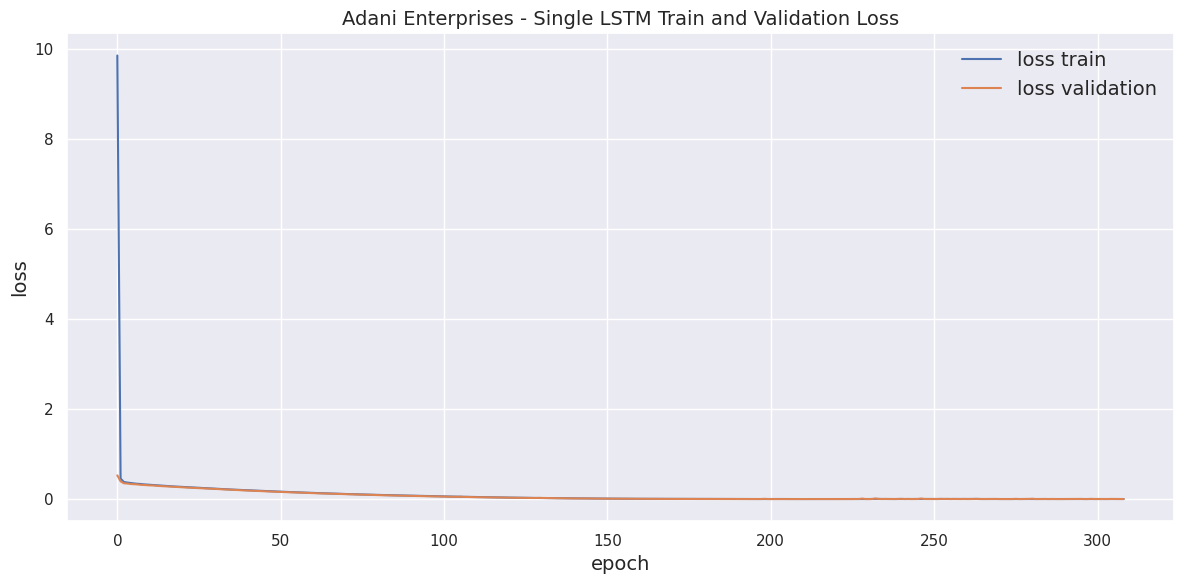

In [60]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Single LSTM Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani_Enterprises_Single_LSTM_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [61]:
# Training dates
date_train = merged_data['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = merged_data['Date'][-len(y_test):]

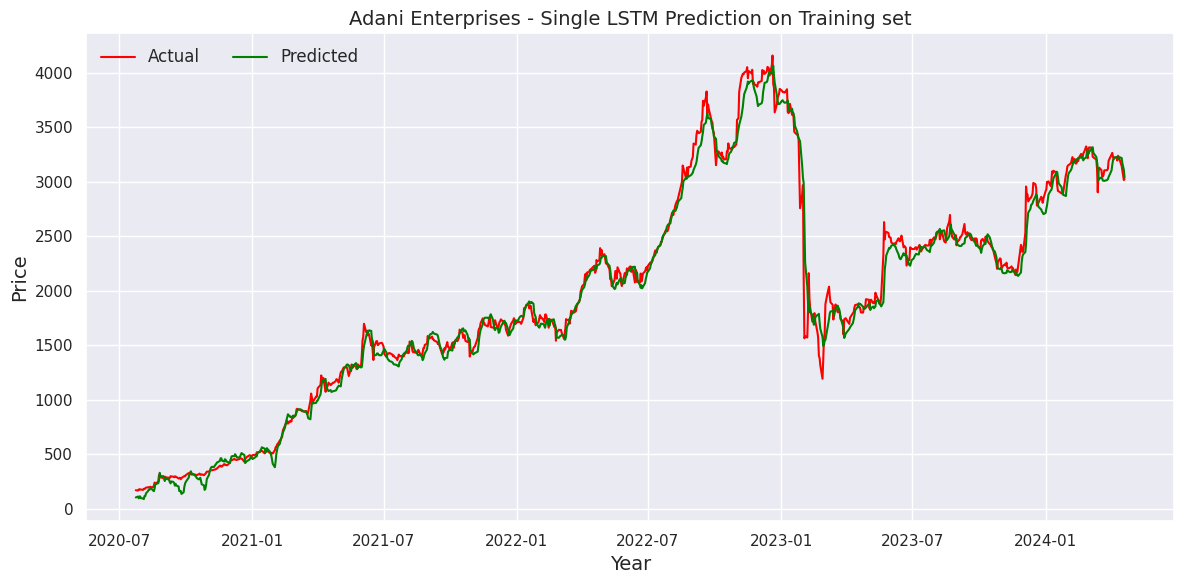

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = merged_data['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Single LSTM Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani_Enterprises_Single_LSTM__Prediction_Train_Set.png"))
plt.show()
plt.close()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


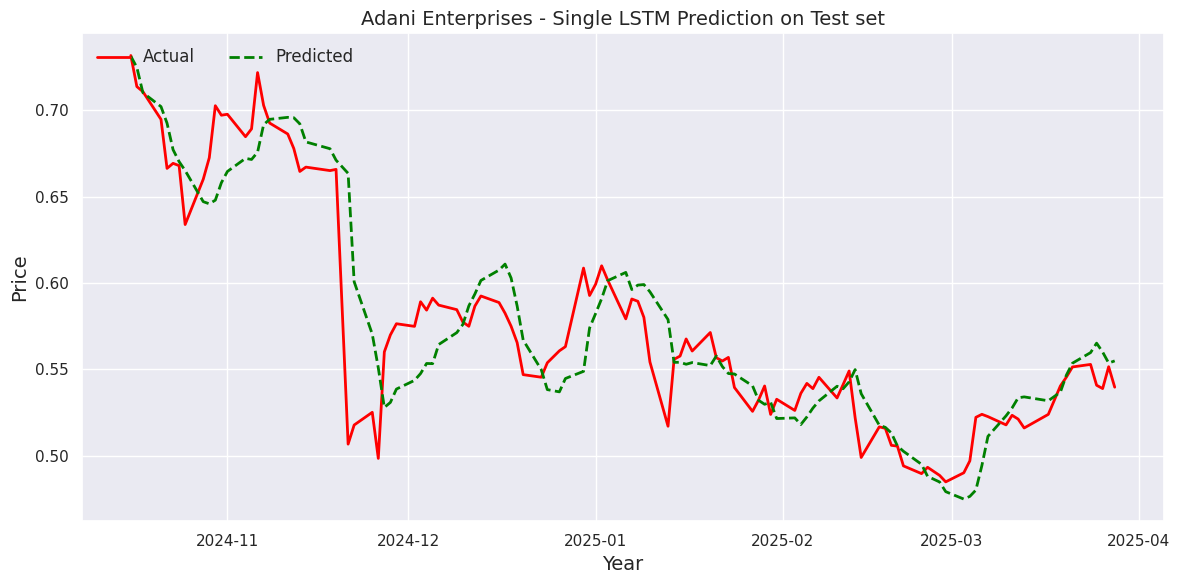

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Single LSTM Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani_Enterprises_Single_LSTM_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


### Single GRU

In [64]:
from tensorflow.keras.layers import GRU
from tensorflow.keras import regularizers
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential([
    GRU(
        units=best_params["units"],
        input_shape=(x_train.shape[1], x_train.shape[2]),
        kernel_regularizer=regularizers.l2(0.001),  # small L2
        recurrent_regularizer=regularizers.l2(1e-4)
    ),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 1250)           │     4,785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 1250)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │         1,251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,786,251 (18.26 MB)

 Trainable params: 4,786,251 (18.26 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

Epoch 1/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 10.5739 - val_loss: 0.3915
Epoch 2/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4257 - val_loss: 0.3131
Epoch 3/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4081 - val_loss: 0.3108
Epoch 4/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3841 - val_loss: 0.3139
Epoch 5/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3739 - val_loss: 0.3090
Epoch 6/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3663 - val_loss: 0.3090
Epoch 7/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3557 - val_loss: 0.3095
Epoch 8/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3476 - val_loss: 0.3043
Epoch 9/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3406 - val_loss: 0.3028
Epoch 10/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3326 - val_loss: 0.3039
Epoch 11/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3274 - val_loss: 0.3036
Epoch 12/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/ste

In [66]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [67]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


Train -> MSE: 8717.1526, MAE: 59.0003, R2: 0.9913
Test -> MSE: 10776.5605, MAE: 70.5698, R2: 0.8363


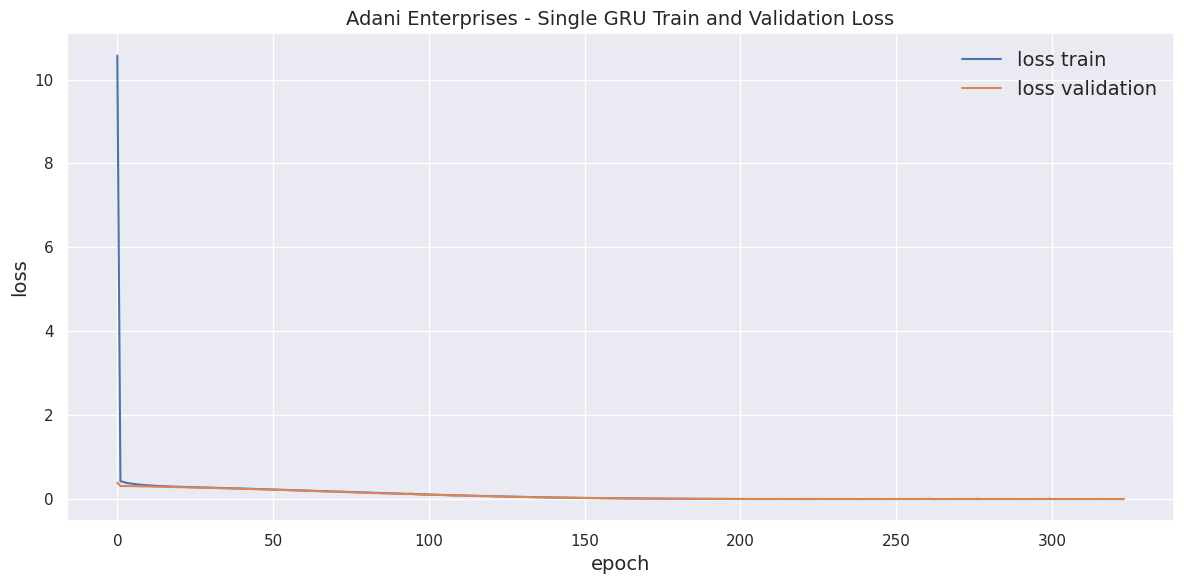

In [68]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Single GRU Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani_Enterprises_Single_GRU_Train and Validation Loss.png"))
plt.show()
plt.close()

In [69]:
# Training dates
date_train = merged_data['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = merged_data['Date'][-len(y_test):]

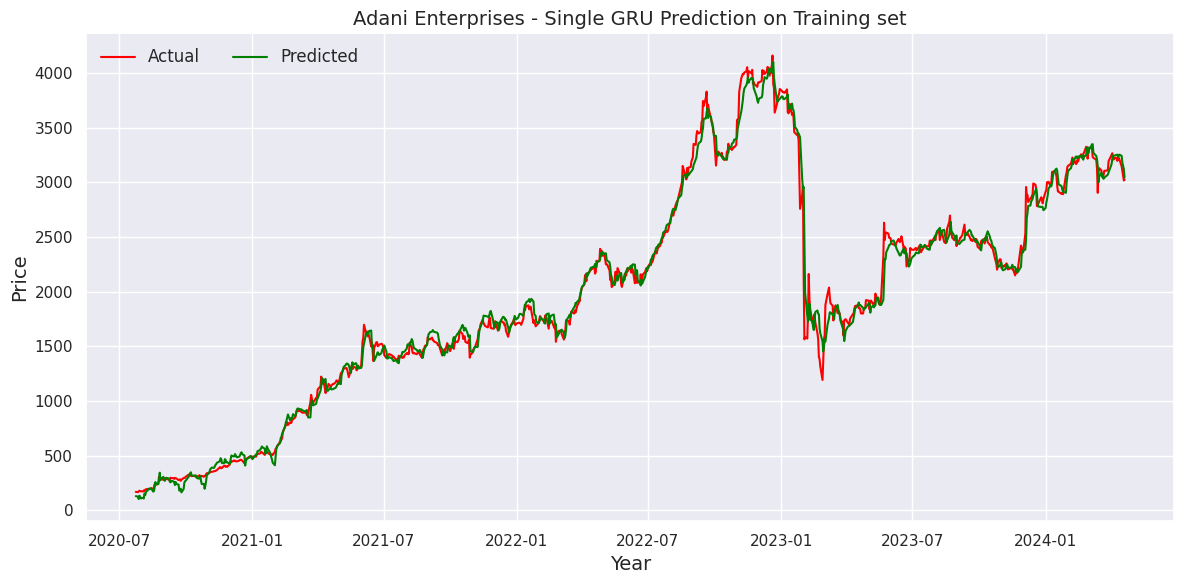

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = merged_data['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Single GRU Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani_Enterprises_Single_GRU_Prediction_Train_Set.png"))
plt.show()
plt.close()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


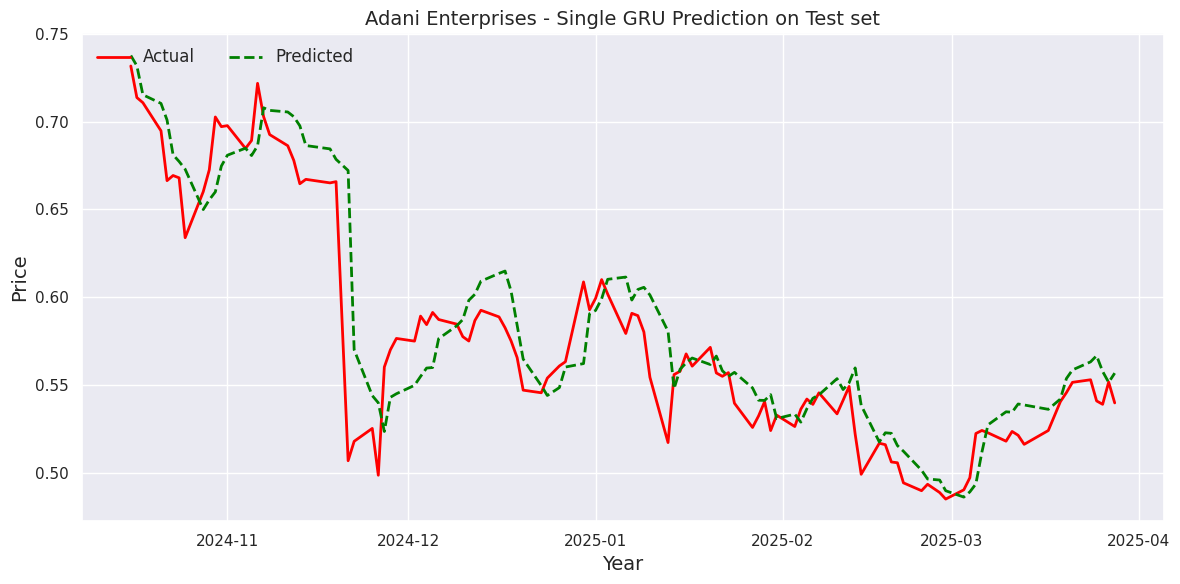

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Single GRU Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani_Enterprises_Single_GRU_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


### Bi-Directional Single LSTM

In [72]:
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
import tensorflow as tf

# Optimizer setup
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

# Model definition
model = Sequential([
    Bidirectional(
        LSTM(
            units=best_params["units"],
            input_shape=(x_train.shape[1], x_train.shape[2]),
            kernel_regularizer=regularizers.l2(0.001),   # small L2
            recurrent_regularizer=regularizers.l2(1e-4)
        )
    ),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])

# Compile model
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

Epoch 1/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 18.0598 - val_loss: 0.7146
Epoch 2/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.8101 - val_loss: 0.6986
Epoch 3/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.7780 - val_loss: 0.6853
Epoch 4/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.7588 - val_loss: 0.7453
Epoch 5/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.7372 - val_loss: 0.6648
Epoch 6/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.7100 - val_loss: 0.6617
Epoch 7/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6950 - val_loss: 0.6462
Epoch 8/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6883 - val_loss: 0.6639
Epoch 9/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6611 - val_loss: 0.6266
Epoch 10/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.6500 - val_loss: 0.6167
Epoch 11/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.6345 - val_loss: 0.6080
Epoch 12/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/ste

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [76]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")

Train -> MSE: 13028.7202, MAE: 71.5795, R2: 0.9871
Test -> MSE: 15332.7328, MAE: 84.9986, R2: 0.7670


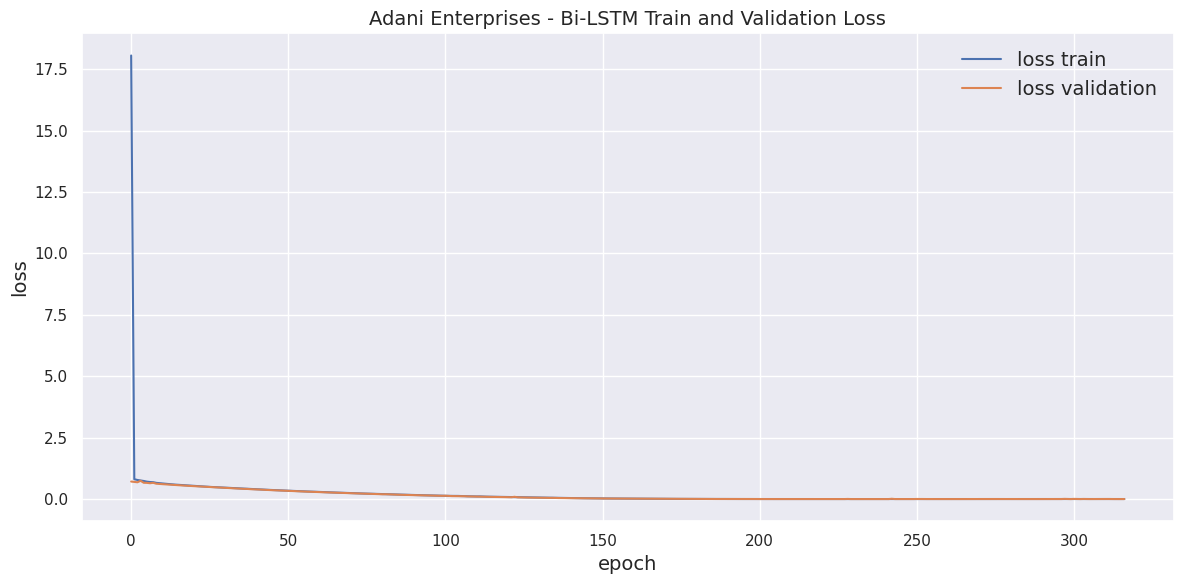

In [77]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Bi-LSTM Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani_Enterprises_BLSTM_Train and Validation Loss.png"))
plt.show()
plt.close()

In [78]:
# Training dates
date_train = merged_data['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = merged_data['Date'][-len(y_test):]

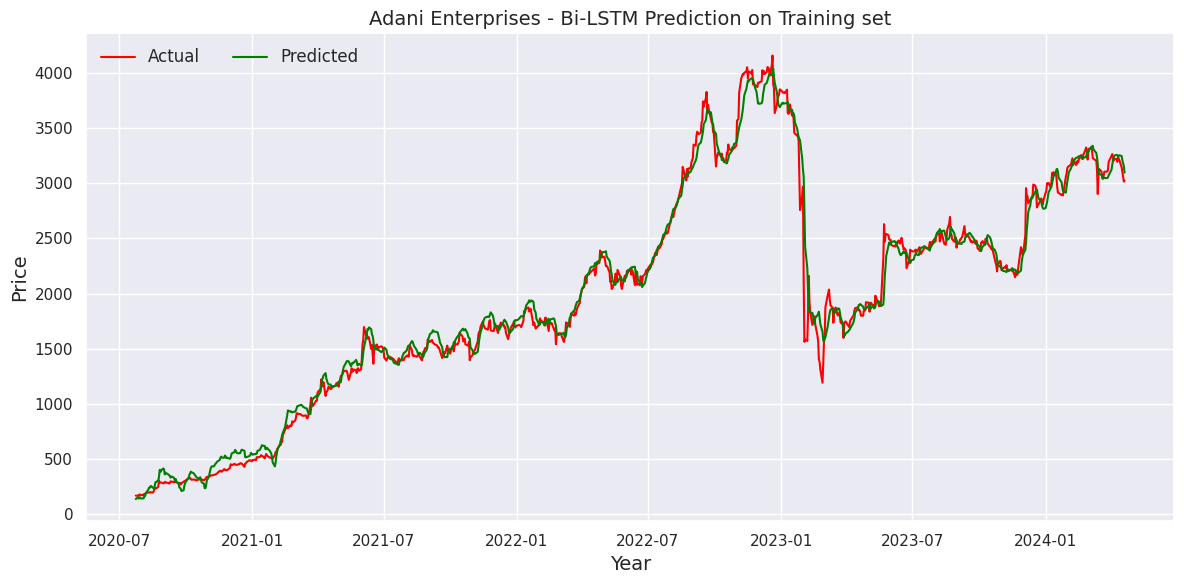

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = merged_data['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Bi-LSTM Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani_Enterprises_BLSTM_Prediction_Train_Set.png"))
plt.show()
plt.close()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


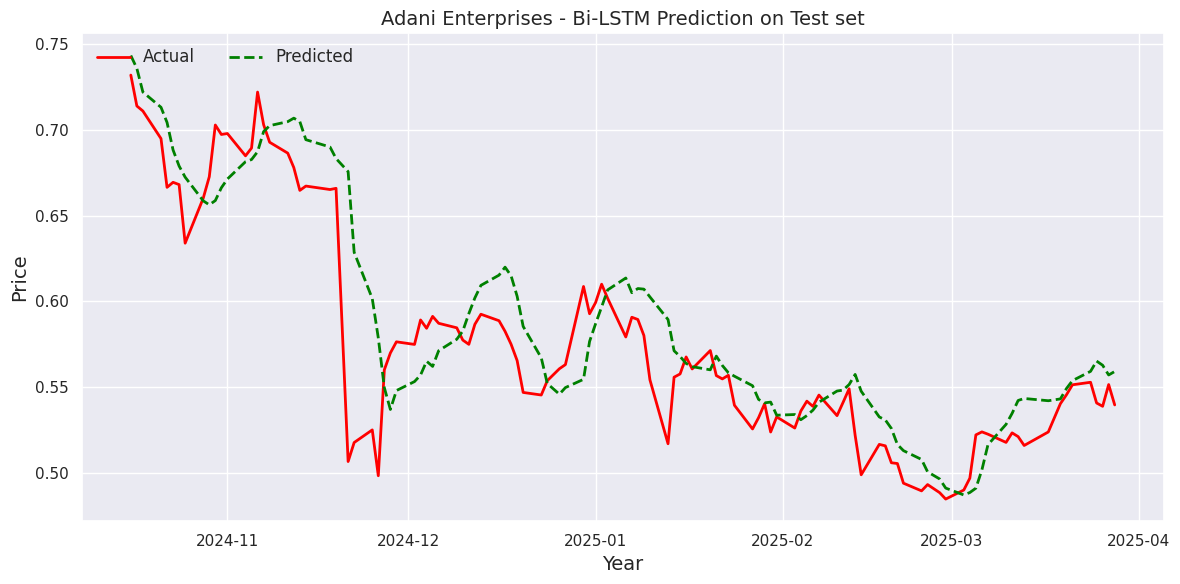

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Bi-LSTM Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani_Enterprises_BLSTM_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#

### Bi-Directional Single GRU

In [81]:
from tensorflow.keras.layers import Bidirectional, GRU, Dropout, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
import tensorflow as tf

# Optimizer setup
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

# Model definition
model = Sequential([
    Bidirectional(
        GRU(
            units=best_params["units"],
            input_shape=(x_train.shape[1], x_train.shape[2]),
            kernel_regularizer=regularizers.l2(0.001),   # small L2
            recurrent_regularizer=regularizers.l2(1e-4)
        )
    ),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])

# Compile model
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [83]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

Epoch 1/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 13.9172 - val_loss: 0.6020
Epoch 2/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6857 - val_loss: 0.5926
Epoch 3/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6638 - val_loss: 0.5923
Epoch 4/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6445 - val_loss: 0.5906
Epoch 5/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6387 - val_loss: 0.5827
Epoch 6/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.6287 - val_loss: 0.5850
Epoch 7/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6167 - val_loss: 0.5783
Epoch 8/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6097 - val_loss: 0.5753
Epoch 9/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.6027 - val_loss: 0.5679
Epoch 10/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5931 - val_loss: 0.5641
Epoch 11/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.5865 - val_loss: 0.5651
Epoch 12/750
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/ste

In [84]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [85]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")

Train -> MSE: 13013.2253, MAE: 80.9132, R2: 0.9871
Test -> MSE: 14299.4567, MAE: 86.5668, R2: 0.7827


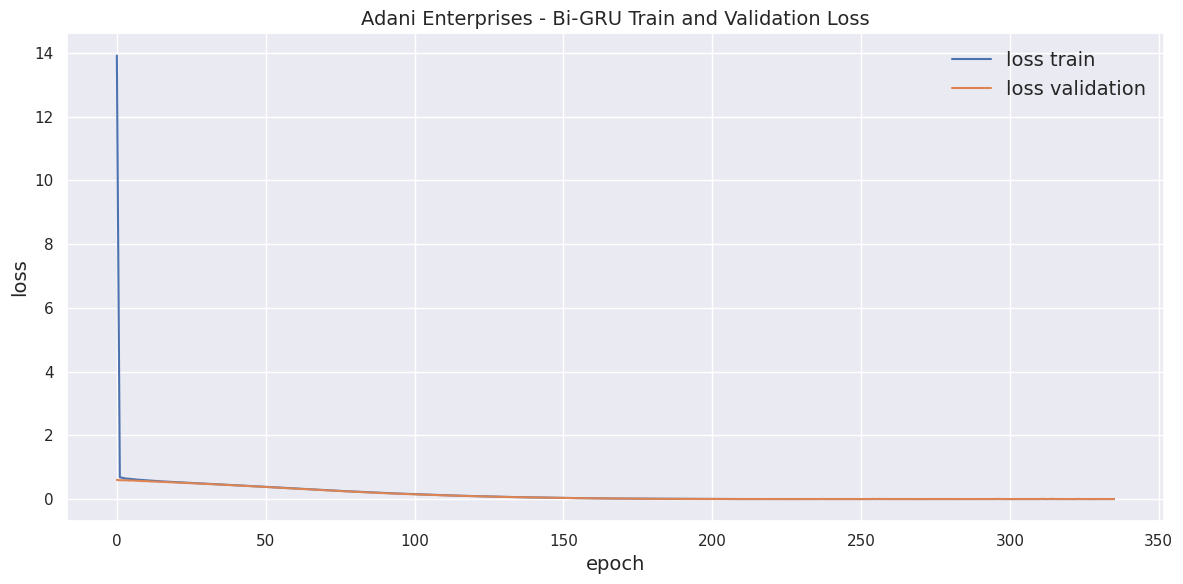

In [86]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Bi-GRU Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani_Enterprises_BiGRU_Train and Validation Loss.png"))
plt.show()
plt.close()

In [87]:
# Training dates
date_train = merged_data['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = merged_data['Date'][-len(y_test):]

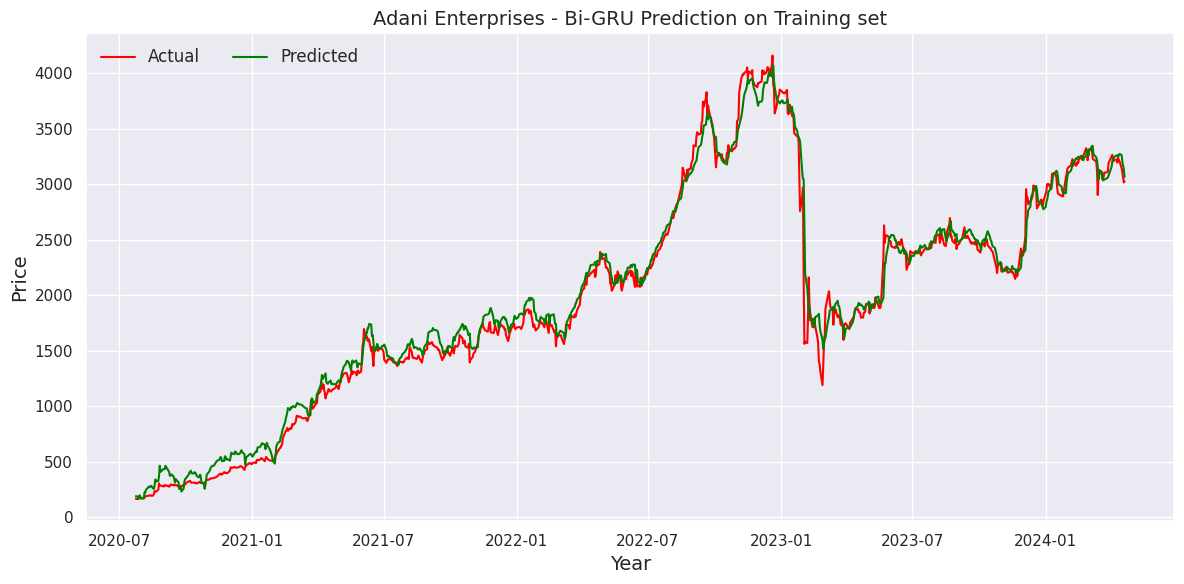

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = merged_data['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Bi-GRU Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani_Enterprises_BiGRU_Prediction_Train_Set.png"))
plt.show()
plt.close()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


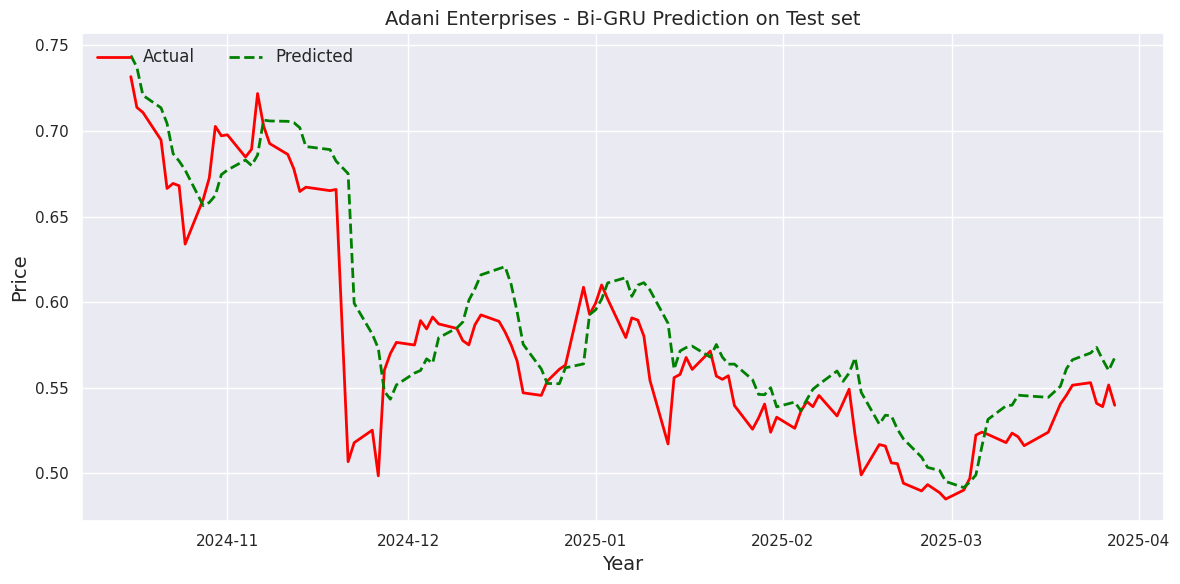

In [89]:


import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Bi-GRU Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani_Enterprises_BiGRU_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#

### Stacked LSTM

In [ ]:
from tensorflow.keras import regularizers
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential()
model.add(LSTM(units=best_params['units_1'], return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(rate=best_params['dropout_rate_1']))
model.add(LSTM(units=best_params['units_2'], return_sequences=True))
model.add(Dropout(rate=best_params['dropout_rate_2']))
model.add(LSTM(units=best_params['units_3'], return_sequences=True))
model.add(Dropout(rate=best_params['dropout_rate_3']))
model.add(LSTM(units=best_params['units_4']))
model.add(Dropout(rate=best_params['dropout_rate_4']))
model.add(Dense(units=1))

model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [ ]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


In [ ]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Stacked LSTM Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani-Enterprises_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [ ]:
# Training dates
date_train = df['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = df['Date'][-len(y_test):]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = df['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Stacked LSTM Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani-Enterprises_Prediction_Train_Set.png"))
plt.show()
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Stacked LSTM Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani-Enterprises_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


# Single GRU

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GRU
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential([
    GRU(
        units=best_params["units"],
        input_shape=(x_train.shape[1], x_train.shape[2]),
        kernel_regularizer=regularizers.l2(0.001),  # small L2
        recurrent_regularizer=regularizers.l2(1e-4)
    ),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [ ]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


In [ ]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Reliance Industries - Single GRU Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Reliance_Industries_Single_GRU_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [ ]:
# Training dates
date_train = df['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = df['Date'][-len(y_test):]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = merged_data['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Reliance Industries - Single GRU Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Reliance-Industries_Single_GRU_Prediction_Train_Set.png"))
plt.show()
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Reliance Industries - Single GRU Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Reliance-Industries_Single_GRU_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


# Stacked GRU

In [ ]:
from tensorflow.keras import regularizers
optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential()
model.add(GRU(units=best_params['units_1'], return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(rate=best_params['dropout_rate_1']))
model.add(GRU(units=best_params['units_2'], return_sequences=True))
model.add(Dropout(rate=best_params['dropout_rate_2']))
model.add(GRU(units=best_params['units_3'], return_sequences=True))
model.add(Dropout(rate=best_params['dropout_rate_3']))
model.add(GRU(units=best_params['units_4']))
model.add(Dropout(rate=best_params['dropout_rate_4']))
model.add(Dense(units=1))

model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [ ]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


In [ ]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Reliance Industries - Stacked GRU Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Reliance_Industries_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [ ]:
# Training dates
date_train = df['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = df['Date'][-len(y_test):]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = df['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Reliance Industries - Stacked GRU Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Reliance-Industries_Prediction_Train_Set.png"))
plt.show()
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Reliance Industries - Stacked GRU Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Reliance-Industries_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


# Bi-Directional Single LSTM

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense

optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential([
    Bidirectional(LSTM(
        units=best_params["units"],
        input_shape=(x_train.shape[1], x_train.shape[2]),
        kernel_regularizer=regularizers.l2(0.001),
        recurrent_regularizer=regularizers.l2(1e-4)
    )),
    Dropout(rate=best_params["dropout_rate"]),
    Dense(1)
])
model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [ ]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


In [ ]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Adani Enterprises - Bi-Directional Single LSTM Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Adani-Enterprises_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [ ]:
# Training dates
date_train = df['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = df['Date'][-len(y_test):]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = df['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Adani Enterprises - Bi-Directional Single LSTM Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Adani-Enterprises_Prediction_Train_Set.png"))
plt.show()
plt.close()
    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Adani Enterprises - Bi-Directional Single LSTM Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Adani-Enterprises_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


# Bi-Directional Stacked LSTM 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras import regularizers

optimizer_class = getattr(tf.keras.optimizers, best_params["optimizer"])
optimizer = optimizer_class(learning_rate=best_params["learning_rate"])

model = Sequential()
model.add(Bidirectional(
    LSTM(units=best_params['units_1'],
         return_sequences=True,
         input_shape=(x_train.shape[1], x_train.shape[4]),
         kernel_regularizer=regularizers.l2(0.001),
         recurrent_regularizer=regularizers.l2(1e-4)
    )
))
model.add(Dropout(rate=best_params['dropout_rate_1']))
model.add(Bidirectional(
    LSTM(units=best_params['units_2'], return_sequences=True,
         kernel_regularizer=regularizers.l2(0.001),
         recurrent_regularizer=regularizers.l2(1e-4)
    )
))
model.add(Dropout(rate=best_params['dropout_rate_2']))
model.add(Bidirectional(
    LSTM(units=best_params['units_3'], return_sequences=True,
         kernel_regularizer=regularizers.l2(0.001),
         recurrent_regularizer=regularizers.l2(1e-4)
    )
))
model.add(Dropout(rate=best_params['dropout_rate_3']))
model.add(Bidirectional(
    LSTM(units=best_params['units_4'],
         kernel_regularizer=regularizers.l2(0.001),
         recurrent_regularizer=regularizers.l2(1e-4)
    )
))
model.add(Dropout(rate=best_params['dropout_rate_4']))
model.add(Dense(units=1))

model.compile(loss="mean_squared_error", optimizer=optimizer)
model.summary()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=100,          # Stop after 200 epochs without improvement
    restore_best_weights=True,  # Roll back to best weights
    verbose=1
)


# %%time
history = model.fit(x_train, y_train, epochs=best_params['epochs'], validation_data=(x_val, y_val), 
batch_size=best_params['batch_size'], callbacks=[early_stop],verbose=1)

# Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_and_print(x, y, dataset_name):
    y_pred = model.predict(x, verbose=0)
    y_pred_inv = target_scaler.inverse_transform(y_pred)
    y_inv = target_scaler.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    r2 = r2_score(y_inv, y_pred_inv)

    print(f"{dataset_name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return y_inv, y_pred_inv

In [ ]:
y_train_inv, y_train_pred_inv = evaluate_and_print(x_train, y_train, "Train")
y_test_inv, y_test_pred_inv = evaluate_and_print(x_test, y_test, "Test")


In [ ]:
import seaborn as sns   
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})
plt.title(f"Reliance Industries - Bi-Directional Stacked LSTM Train and Validation Loss", fontsize=14)
plt.plot(history.history['loss'], label='loss train')
plt.plot(history.history['val_loss'], label='loss validation')
plt.xlabel('epoch', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(stock_dir, f"Reliance_Industries_Bi-Directional Stacked_Train and Validation Loss.png"))
plt.show()
plt.close()

# Plotting Predictions

In [ ]:
# Training dates
date_train = df['Date'][LAG_DAYS : len(y_train) + LAG_DAYS]

# Testing dates
date_test = df['Date'][-len(y_test):]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Dates aligned with LAG_DAYS offset
date_train = df['Date'][LAG_DAYS:len(y_train_inv) + LAG_DAYS]

# Plot
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

plt.title("Reliance Industries - Bi-Directional Stacked Prediction on Training set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

plt.plot(date_train, y_train_inv, label='Actual', color='red')
plt.plot(date_train, y_train_pred_inv, label='Predicted', color='green')

plt.legend(loc="upper left", fontsize=12, ncol=2)
plt.tight_layout()

plt.savefig(os.path.join(stock_dir, "Reliance-Industries_Bi-Directional_Stacked_Prediction_Train_Set.png"))
plt.show()
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

yhat_test = model.predict(x_test)
assert len(date_test) == len(y_test) == len(yhat_test), "Length mismatch in test data plotting"
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (12, 6)})

# Title & labels
plt.title("Reliance Industries - Bi-Directional Stacked Prediction on Test set", fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Plot actual vs predicted
plt.plot(date_test, y_test, label='Actual', color='red', linewidth=2)
plt.plot(date_test, yhat_test, label='Predicted', color='green', linestyle='--', linewidth=2)

# Legend
plt.legend(loc="upper left", fontsize=12, ncol=2)

# Layout
plt.tight_layout()

# Save plot
plot_filename = os.path.join(stock_dir, "Reliance-Industries_Bi-Directional Stacked_Prediction_Test_Set.png")
plt.savefig(plot_filename, dpi=300)

#


In [ ]:
# Configuration parameters
class Config:
    ARO_RABBITS = 10
    ARO_ITERATIONS = 50
    FINAL_EPOCHS = 100


class ARO:
    def __init__(self, n_rabbits, n_iterations, search_space, objective_func):
        self.n_rabbits = n_rabbits
        self.n_iterations = n_iterations
        self.search_space = search_space
        self.objective_func = objective_func
        self.dimension = len(search_space)
        self.rabbits = np.zeros((n_rabbits, self.dimension))
        self.fitness = np.zeros(n_rabbits)
        self.best_rabbit = None
        self.best_fitness = float('inf')
        
    def initialize_rabbits(self):
        for i in range(self.n_rabbits):
            for j in range(self.dimension):
                self.rabbits[i, j] = np.random.uniform(
                    self.search_space[j][0], 
                    self.search_space[j][1]
                )
            self.fitness[i] = self.objective_func(self.rabbits[i])
            
            if self.fitness[i] < self.best_fitness:
                self.best_fitness = self.fitness[i]
                self.best_rabbit = self.rabbits[i].copy()
    
    def update_rabbits(self, iteration):
        for i in range(self.n_rabbits):
            # Exploration phase (searching for food)
            if np.random.rand() < 0.5:
                r1 = np.random.randint(0, self.n_rabbits)
                while r1 == i:
                    r1 = np.random.randint(0, self.n_rabbits)
                
                new_position = self.rabbits[i] + np.random.rand() * (
                    self.rabbits[r1] - self.rabbits[i]
                )
            # Exploitation phase (eating food)
            else:
                new_position = self.rabbits[i] + np.random.rand() * (
                    self.best_rabbit - self.rabbits[i]
                )
            
            # Apply bounds
            for j in range(self.dimension):
                if new_position[j] < self.search_space[j][0]:
                    new_position[j] = self.search_space[j][0]
                elif new_position[j] > self.search_space[j][1]:
                    new_position[j] = self.search_space[j][1]
            
            # Evaluate new position
            new_fitness = self.objective_func(new_position)
            
            # Update if better
            if new_fitness < self.fitness[i]:
                self.rabbits[i] = new_position
                self.fitness[i] = new_fitness
                
                if new_fitness < self.best_fitness:
                    self.best_fitness = new_fitness
                    self.best_rabbit = new_position.copy()
    
    def optimize(self):
        self.initialize_rabbits()
        
        for it in range(self.n_iterations):
            self.update_rabbits(it)
            
            if it % 10 == 0:
                print(f"Iteration {it}, Best Fitness: {self.best_fitness}")
        
        return self.best_rabbit, self.best_fitness

### Model Architecture and Objective Function

In [ ]:
from tensorflow.keras.optimizers import Adam
def create_lstm_model(input_shape, layers, units, dropout_rate, learning_rate):
    """
    Create an LSTM model with the specified architecture
    """
    model = Sequential()
    
    # First LSTM layer
    model.add(LSTM(units=units[0], return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    
    # Additional LSTM layers
    for i in range(1, layers):
        if i == layers - 1:
            model.add(LSTM(units=units[i], return_sequences=False))
        else:
            model.add(LSTM(units=units[i], return_sequences=True))
        model.add(Dropout(dropout_rate))
    
    # Output layer
    model.add(Dense(units=1))
    
    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    return model

def objective_function(params):
    """
    Objective function for ARO optimization
    """
    layers = int(params[0])
    units = [int(params[1])] * layers
    dropout_rate = params[2]
    learning_rate = params[3]
    batch_size = int(params[4])
    
    # Create and train the model
    model = create_lstm_model(
        input_shape=(x_train.shape[1], x_train.shape[2]),
        layers=layers,
        units=units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )
    
    history = model.fit(
        x_train, y_train,
        epochs=20,  # Use fewer epochs for optimization
        batch_size=batch_size,
        validation_data=(x_test, y_test),
        verbose=0
    )
    
    # Return validation loss
    return history.history['val_loss'][-1]

### Evaluation and Visualization Functions

In [ ]:
def calculate_metrics(actual, predicted):
    """
    Calculate evaluation metrics
    """
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    
    return mse, mae, mape, r2

def plot_results(actual, predicted, history, stock_symbol):
    """
    Plot the actual vs predicted prices and training history
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot actual vs predicted prices
    ax1.plot(actual, label='Actual Price', color='blue')
    ax1.plot(predicted, label='Predicted Price', color='red')
    ax1.set_title(f'{stock_symbol} Stock Price Prediction')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Plot training history
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{stock_symbol}_prediction_results.png')
    plt.show()

# Bi-Directional LSTM

In [ ]:
# Define search space for ARO
search_space = [
    (1, 4),      # Number of LSTM layers
    (32, 128),   # Number of units per layer
    (0.1, 0.5),  # Dropout rate
    (0.001, 0.1), # Learning rate
    (16, 64)     # Batch size
    ]

# Initialize and run ARO
print("Starting ARO optimization...")
aro = ARO(
    n_rabbits=Config.ARO_RABBITS,
    n_iterations=Config.ARO_ITERATIONS,
    search_space=search_space,
    objective_func=objective_function
)

best_params, best_fitness = aro.optimize()

print(f"Best parameters: {best_params}")
print(f"Best validation loss: {best_fitness}")

# Extract best parameters
best_layers = int(best_params[0])
best_units = [int(best_params[1])] * best_layers
best_dropout = best_params[2]
best_learning_rate = best_params[3]
best_batch_size = int(best_params[4])

# Train the final model with best parameters
print("Training final model...")
final_model = create_lstm_model(
    input_shape=(x_train.shape[1], x_train.shape[2]),
    layers=best_layers,
    units=best_units,
    dropout_rate=best_dropout,
    learning_rate=best_learning_rate
)

history = final_model.fit(
    x_train, y_train,
    epochs=Config.FINAL_EPOCHS,
    batch_size=best_batch_size,
    validation_data=(x_test, y_test),
    verbose=1
)



In [ ]:
# Make predictions
train_predict = final_model.predict(x_train)
test_predict = final_model.predict(x_test)

# Inverse transform the predictions
# Create dummy arrays for inverse transformation
dummy_array_train = np.zeros((len(train_predict), len(feature_columns)))
dummy_array_test = np.zeros((len(test_predict), len(feature_columns)))

# Place predictions in the Close price column (index 3)
dummy_array_train[:, 3] = train_predict.flatten()
dummy_array_test[:, 3] = test_predict.flatten()

# Inverse transform
train_predict = scaler.inverse_transform(dummy_array_train)[:, 3]
test_predict = scaler.inverse_transform(dummy_array_test)[:, 3]

# Get actual values
dummy_array_ytrain = np.zeros((len(y_train), len(feature_columns)))
dummy_array_ytest = np.zeros((len(y_test), len(feature_columns)))

dummy_array_ytrain[:, 3] = y_train.flatten()
dummy_array_ytest[:, 3] = y_test.flatten()

y_train_actual = scaler.inverse_transform(dummy_array_ytrain)[:, 3]
y_test_actual = scaler.inverse_transform(dummy_array_ytest)[:, 3]

# Calculate metrics
mse, mae, mape, r2 = calculate_metrics(y_test_actual, test_predict)

print("\nEvaluation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mae:.2f}%")
print(f"R²: {r2:.4f}")

# Plot results
all_actual = np.concatenate([y_train_actual, y_test_actual])
all_predicted = np.concatenate([train_predict, test_predict])

plot_results(all_actual, all_predicted, history, Config.STOCK_SYMBOL)

# Save the model
final_model.save(f"{Config.STOCK_SYMBOL}_price_prediction_model.h5")
print("Model saved successfully!")